[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# GARTEUR SM-AG19 Testbed: Simplified

Last updated: 07/16/26

Description

This virtual test application is based on the test article used by the GARTEUR
Structures & Materials Action Group 19 which organized a Round Robin exercise
where 12 European laboratories tested a single structure between 1995 and 1997.
The benchmark structure was a laboratory structure built to simulate the
dynamic behaviour of an aeroplane. The structure was initially built for a
benchmark study on experimental modal analysis conducted by the Structures and
Materials Action Group (SM-AG19) of the Group for Aeronautical Research and
Technology in EURope (GARTEUR). The test-bed was designed and manufactured by
ONERA, France.


![](IMAC97photo.png)

This tutorial is simplified: no damping, no constraining layer, no 
added masses (not on the drums, no masses for connecting metal).

The purpose is to calculate the natural frequencies and the corresponding mode shapes.
The table below summarizes the frequencies found in the experiment.

| Frequency | Hz |
|----------|----------:|
|  1   | 6.38 |
| 2   | 16.10   |
| 3 | 33.12 |
| 4 | 33.53 |
| 5 | 35.65 |
| 6 | 48.38 |
| 7 | 49.43 | 
| 8 | 55.08 |

References

- [GARTEUR] Ground Vibration Test Techniques, compiled by A Gravelle, GARTEUR
  Structures & Materials Action Group 19 Technical report TP-115, 1999.
- [BW] Etienne Balmes, Jan R. Wright, GARTEUR GROUP ON GROUND VIBRATION
  TESTING | RESULTS FROM THE TEST OF A SINGLE STRUCTURE BY 12 LABORATORIES IN
  EUROPE, Proceedings of DETC'97, 1997 ASME Design Engineering Technical
  Conferences, September 14-17, 1997, Sacramento, California.


## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


In [1]:
import scipy
import context
from math import pi
from numpy import eye, max, diag
from pystran import model
from pystran import section
from pystran import plots

The material is aluminum, SI units (mm).
[GARTEUR] has an indication which material properties were considered
in the original finite element simulations.


In [2]:
E = 72000.0
G = E / (2 * (1 + 0.3))
rho = 2.7e-9 

This parameter indicates how the members of the frame are refined into elements.

In [3]:
nref = 3

The cross section properties are given in SI units (mm).

All cross sections are oriented so that the local z axis is aligned with 
the global z (except for the tail).


In [4]:
xz_vector = [0, 0, 1]
xz_vector_tail = [1, 0, 0]

Body.


In [5]:
A, Ix, Iy, Iz, J = section.rectangle(150.0, 50.0)
sbody = section.beam_3d_section(
    "sbody", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

Wings. 


In [6]:
A, Ix, Iy, Iz, J = section.rectangle(10.0, 100.0)
swing = section.beam_3d_section(
    "swing", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

Constraining layer on the wing.


In [7]:
A, Ix, Iy, Iz, J = section.rectangle(1.0, 76.2)
slayer = section.beam_3d_section(
    "slayer", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

Drums.


In [8]:
A, Ix, Iy, Iz, J = section.rectangle(10.0, 100.0)
sdrum = section.beam_3d_section(
    "sdrum", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

Tail.


In [9]:
A, Ix, Iy, Iz, J = section.rectangle(100.0, 10.0)
stail = section.beam_3d_section(
    "stail", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector_tail
)

Tailplane.


In [10]:
A, Ix, Iy, Iz, J = section.rectangle(10.0, 100.0)
stplane = section.beam_3d_section(
    "stplane", E=E, rho=rho, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

The offset beams are connected through rigid links.
The rigidity is considered through a diagonal matrix coupling the degrees of freedom, based on the stiffness of a 1mm long beam of the cross section
corresponding to the wing.


In [11]:
srig = section.rigid_link_section("sr", Gamma=diag([E * 100 * 10, E * 100 * 10, E * 100 * 10, E * 100 * 10**3 / 12, E * 100 * 10**3 / 12, E * 100 * 10**3 / 12]))
print(srig)

{'name': 'sr', 'Gamma': array([[7.2e+07, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00],
       [0.0e+00, 7.2e+07, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00, 7.2e+07, 0.0e+00, 0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00, 0.0e+00, 6.0e+08, 0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 6.0e+08, 0.0e+00],
       [0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 6.0e+08]])}


Create the model.


In [12]:
m = model.create(3)
freedoms = m["freedoms"]

On the body


In [13]:
model.add_joint(m, 1, [0.0, 0.0, 0.0]) # Under wing
model.add_joint(m, 2, [600.0, 0.0, 0.0]) # Nose
model.add_joint(m, 3, [-900.0, 0.0, 0.0]) # Tail end
model.add_joint(m, 4, [-850.0, 0.0, 0.0]) # Under tail 
model.add_joint(m, 5, [-290.0, 0.0, 0.0]) # Attachment of Bungees  

The wing.


In [14]:
model.add_joint(m, 6, [0.0, 0.0, 96.0]) # Wing root (above body)
model.add_joint(m, 7, [0.0, 1000.0, 96.0]) # Left wing tip


model.add_joint(m, 10, [0.0, 850.0, 96.0]) # Left wing intermediate (end of constraining layer)
model.add_joint(m, 11, [0.0, 950.0, 96.0]) # Left wing under drum
model.add_joint(m, 12, [0.0, -1000.0, 96.0]) # Right wing tip


model.add_joint(m, 15, [0.0, -850.0, 96.0]) # Right wing intermediate (end of constraining layer)
model.add_joint(m, 16, [0.0, -950.0, 96.0]) # Right wing under drum

The left drum.


In [15]:
model.add_joint(m, 17, [0.0, 950.0, 106.0]) # Left drum root (above wing)
model.add_joint(m, 18, [200.0, 950.0, 106.0]) # Left drum tip front
model.add_joint(m, 19, [-200.0, 950.0, 106.0]) # Left drum tip rear

The right drum.


In [16]:
model.add_joint(m, 20, [0.0, -950.0, 106.0]) # Right drum root (above wing)
model.add_joint(m, 21, [200.0, -950.0, 106.0]) # Right drum tip front
model.add_joint(m, 22, [-200.0, -950.0, 106.0]) # Right drum tip rear

The tail fin.


In [17]:
model.add_joint(m, 23, [-850.0, 0.0, 50.0]) # Tail fin above body
model.add_joint(m, 24, [-850.0, 0.0, 350.0]) # Tail fin bellow tailplane

The tailplane.


In [18]:
model.add_joint(m, 25, [-850.0, 0.0, 355.0]) # Tailplane above tail fin
model.add_joint(m, 26, [-850.0, 200.0, 355.0]) # Tailplane left tip
model.add_joint(m, 27, [-850.0, -200.0, 355.0]) # Tailplane right tip

Add the body members.


In [19]:
model.add_beam_member(m, 'b1', [1, 2], sbody)
model.add_beam_member(m, 'b2', [1, 5], sbody)
model.add_beam_member(m, 'b3', [3, 4], sbody)
model.add_beam_member(m, 'b4', [4, 5], sbody)

Add the wing members on the left.


In [20]:
model.add_beam_member(m, 'lw1', [6, 10], swing)
model.add_beam_member(m, 'lw4', [10, 11], swing)
model.add_beam_member(m, 'lw5', [11, 7], swing)

Add the wing members on the right.


In [21]:
model.add_beam_member(m, 'rw1', [6, 15], swing)
model.add_beam_member(m, 'rw4', [15, 16], swing)
model.add_beam_member(m, 'rw5', [16, 12], swing)

In [22]:
if nref > 1:
    model.refine_member(m, 'lw1', nref)
    model.refine_member(m, 'rw1', nref)

Add the left drum members.


In [23]:
model.add_beam_member(m, 'ld1', [17, 18], sdrum)
model.add_beam_member(m, 'ld2', [17, 19], sdrum)

Add the right drum members.


In [24]:
model.add_beam_member(m, 'rd1', [20, 21], sdrum)
model.add_beam_member(m, 'rd2', [20, 22], sdrum)

Add the tail fin member.


In [25]:
model.add_beam_member(m, 'tf', [23, 24], stail)

Add the tailplane members.


In [26]:
model.add_beam_member(m, 'ltp1', [25, 26], stplane)
model.add_beam_member(m, 'ltp2', [25, 27], stplane)

Connect the body and the wing


In [27]:
model.add_rigid_link_member(m, 'bwlink', (1, 6), srig)

Connect the left drum and the wing


In [28]:
model.add_rigid_link_member(m, 'dwllink', (11, 17), srig)

Connect the right drum and the wing


In [29]:
model.add_rigid_link_member(m, 'dwrlink', (16, 20), srig)

Connect the body and the tail


In [30]:
model.add_rigid_link_member(m, 'btlink', (4, 23), srig)

Connect the tail and the tailplane


In [31]:
model.add_rigid_link_member(m, 'tplink', (24, 25), srig)

Let us calculate the mass of the model, which can be compared with the data reported in the literature.

In [32]:
vol = model.volume(m)
mass = (rho * vol) 
print('Model mass = ', mass * 1000, '[kg]')

Model mass =  39.82500000000001 [kg]


The mass of the model is rather less than reported in the literature. This is probably due to the lack of  the attachment fixtures and the additional mass on the drums.

Lastly, we need to equip the model with the support: the airframe is suspended on bungees. We shall assume that there are two of them to hold the frame. We can assume that the bungees are of stiffness that can be determined by considering the rigid-body vibration  when the entire mass is suspended on them (median of measured rigid-body frequencies is 2.3 Hz). That gives us an estimate of the stiffness coefficient. Here we will assume the nominal mass, rather than the actual mass. The stiffness coefficient needs to be in N/mm (hence we divide by one thousand).

In [33]:
bungee_stiffness = (2 * pi * 2.3)**2 * 44 / 1000 / 2

Therefore, we can now create a uniaxial spring section, acting in the vertical (z) direction.

In [34]:
sbungee = section.spring_section('bungee', 'extension', [0, 0, 1], bungee_stiffness)


Now we need to create a joint that will represent the "ground" to which the bungees are attached. The "ground" will be assumed to be immovable.

In [35]:
model.add_joint(m, 'ground', [0, 0, 0])
model.add_support(m['joints']['ground'], freedoms.ALL_DOFS)


Finally we create the springs for each of the bungees.

In [36]:
model.add_spring_member(m, 'bungee_front', ['ground', 1], sbungee)
model.add_spring_member(m, 'bungee_rear', ['ground', 5], sbungee)

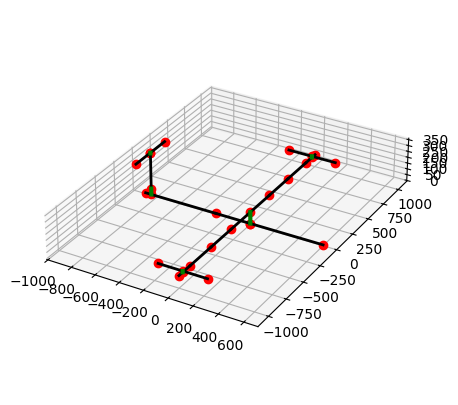

In [37]:
plots.setup(m)
# plots.plot_joint_ids(m)
plots.plot_joints(m)
plots.plot_members(m)
# plots.plot_member_orientation(m)
plots.show(m)

Solve the problem.


In [38]:
model.number_dofs(m)
model.solve_free_vibration(m, 5.0)

Plot the modes and compare the frequencies. The mode shapes correlate with
those published in the reference. Note the experimentally determined frequencies given in the table in the introduction.
In particular, our model predicts 5.83 Hz which should be compared with the 6.38 Hz frequency in the experiment.

Mode 1: 5.924 Hz


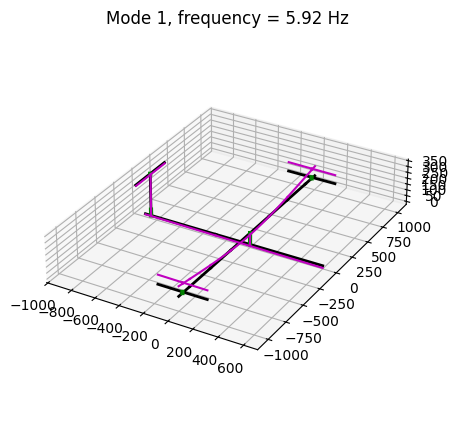

Mode 2: 16.844 Hz


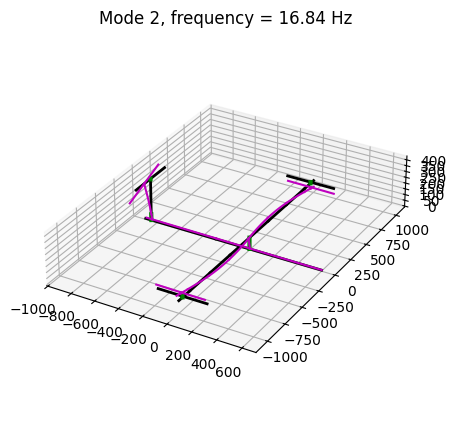

Mode 3: 37.305 Hz


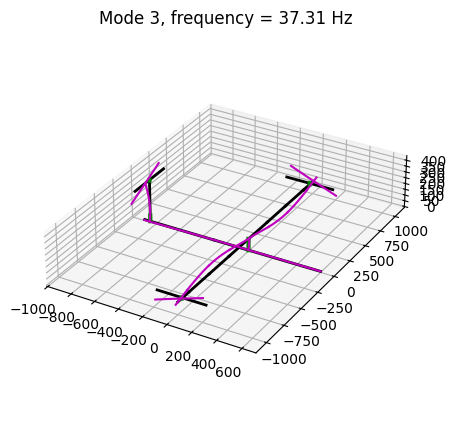

Mode 4: 38.122 Hz


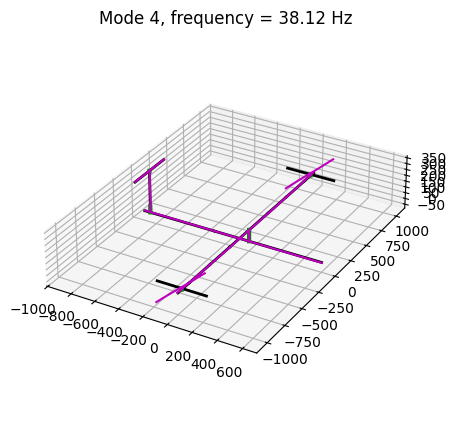

Mode 5: 38.237 Hz


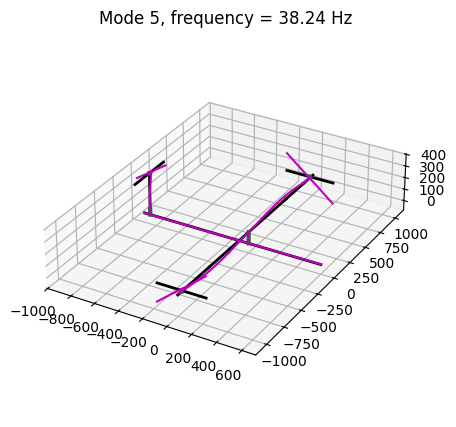

Mode 6: 44.735 Hz


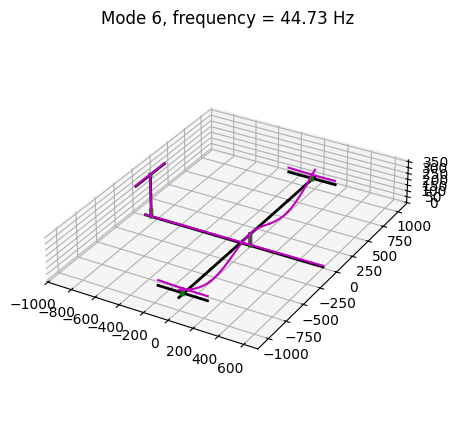

Mode 7: 46.200 Hz


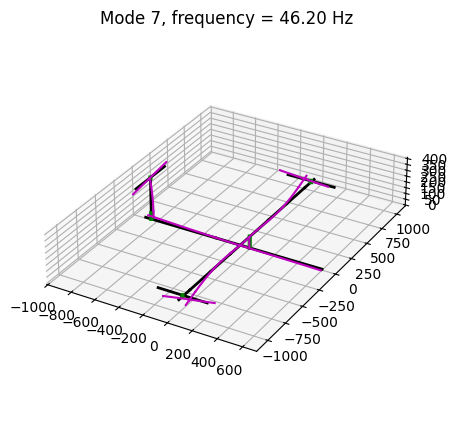

Mode 8: 57.349 Hz


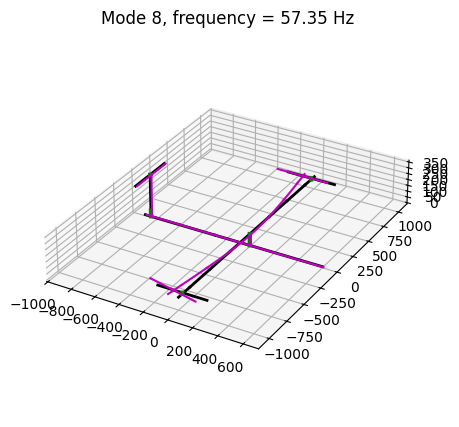

In [39]:
for mode in range(6, 14):
    print(f"Mode {mode+1-6}: {m['frequencies'][mode]:.3f} Hz")
    ax = plots.setup(m)
    plots.plot_members(m)
    model.set_solution(m, m["eigvecs"][:, mode])
    plots.plot_deformations(m, 5.0)
    ax.set_title(f"Mode {mode+1-6}, frequency = {m['frequencies'][mode]:.2f} Hz")
    plots.show(m)
    


## Conclusions

It turns out that omitting the added masses of the fixtures and the compensating masses on the drums, the fundamental frequency slightly increased.
